## Study how different correlations affect power

In [12]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np

In [13]:
# two egde variances 0.5 and 1, only Falserejection, 10k nsim, name=simulation_results_20260122_1816.csv"
# one edge var at 1, 20k nsim, name=simulation_results_20260123_1022.csv
# rho 05, 099 simulation_results_20260124_2058
results = pd.read_csv("simulation_results_20260211_1024.csv")

In [14]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

In [15]:
results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))
results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x.get('FalseRejection', np.nan))
results['Rejection'] = results['ComputeAll'].apply(lambda x: x.get('Rejection', np.nan))
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x.get('TrueRejection', np.nan))

In [16]:
results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['copula_type'] = results['dgp'].apply(lambda x: x.split('_')[1])

### Defining different aggregations

In [17]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [18]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[(results_gaussian["rho"] == "0.01")].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["rho"] == "0.1")].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == "0.2")].copy()


results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.5")
].copy()
results_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.01")
].copy()
results_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.1")
].copy()
results_alt_02_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.2")
].copy()

In [22]:
agg_null_gaussian = aggregate_results(results_null_gaussian, 
                                      y_axis="TrueRejection",
                                      x_axis="n",
                                      factors=["edge_var", "copula_type", "method"])

agg_alt_05_gaussian = aggregate_results(results_alt_05_gaussian, 
                                        y_axis="TrueRejection",
                                        x_axis="n",
                                        factors=["edge_var", "copula_type", "method"])

agg_alt_01_gaussian = aggregate_results(results_alt_01_gaussian, 
                                        y_axis="TrueRejection",
                                        x_axis="n",
                                        factors=["edge_var", "copula_type", "method"])

agg_alt_02_gaussian = aggregate_results(results_alt_02_gaussian,
                                         y_axis="TrueRejection",
                                         x_axis="n",
                                         factors=["edge_var", "copula_type", "method"])

agg_alt_05_bernoulli = aggregate_results(results_alt_05_bernoulli,
                                         y_axis="TrueRejection",
                                         x_axis="n",
                                         factors=["edge_var", "copula_type", "method"])
agg_alt_02_bernoulli = aggregate_results(results_alt_02_bernoulli,
                                         y_axis="TrueRejection",
                                         x_axis="n",
                                         factors=["edge_var", "copula_type", "method"])

## Plots

### Gaussian Network

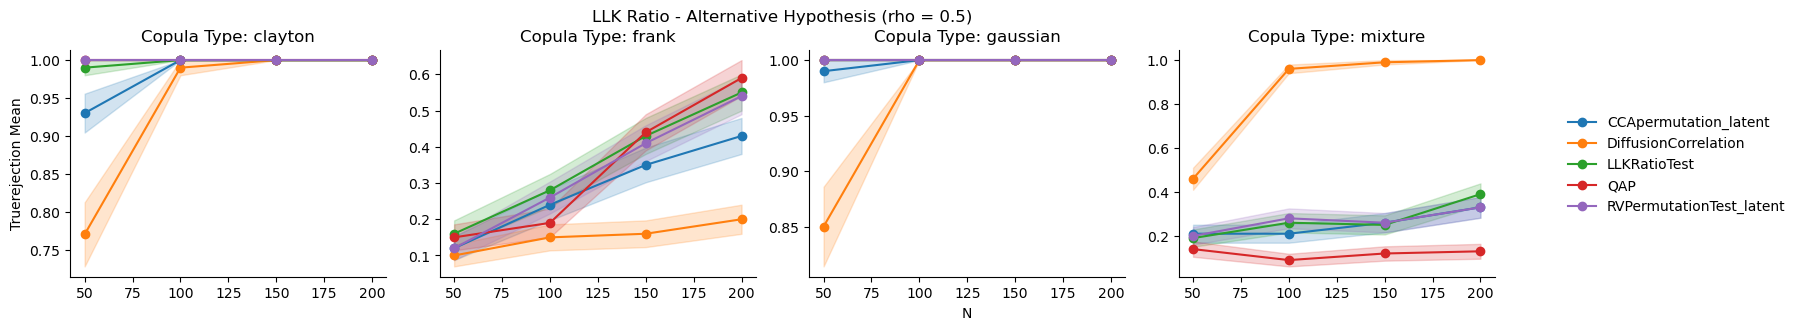

In [ ]:
plot_grid(
    grouped_stats=agg_alt_05_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Gaussian network rho 0.5",
)

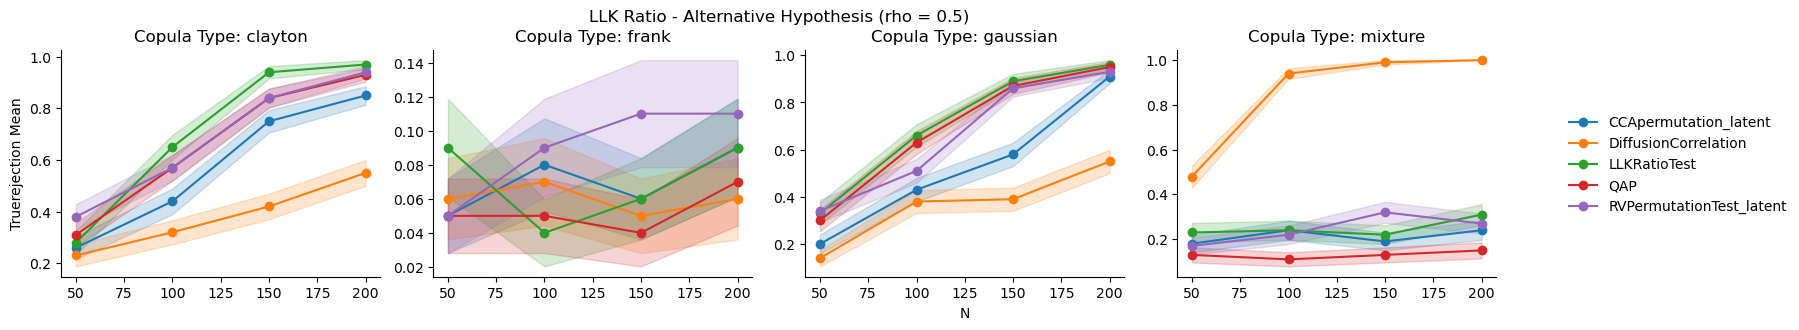

In [ ]:
plot_grid(
    grouped_stats=agg_alt_02_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="gaussian network rho = 0.2",
)

### Bernoulli network

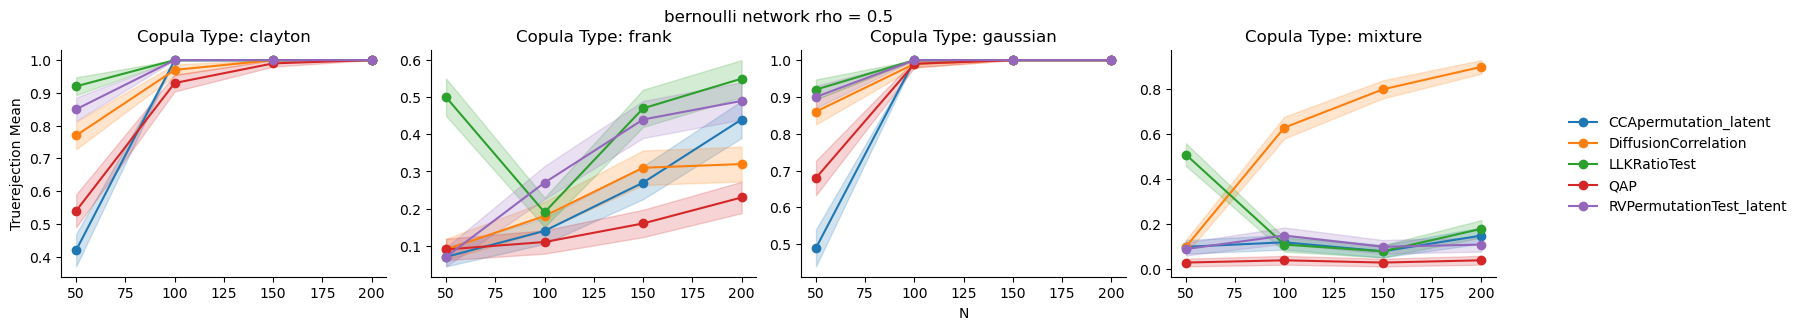

In [25]:
plot_grid(
    grouped_stats=agg_alt_05_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="bernoulli network rho = 0.5",
)

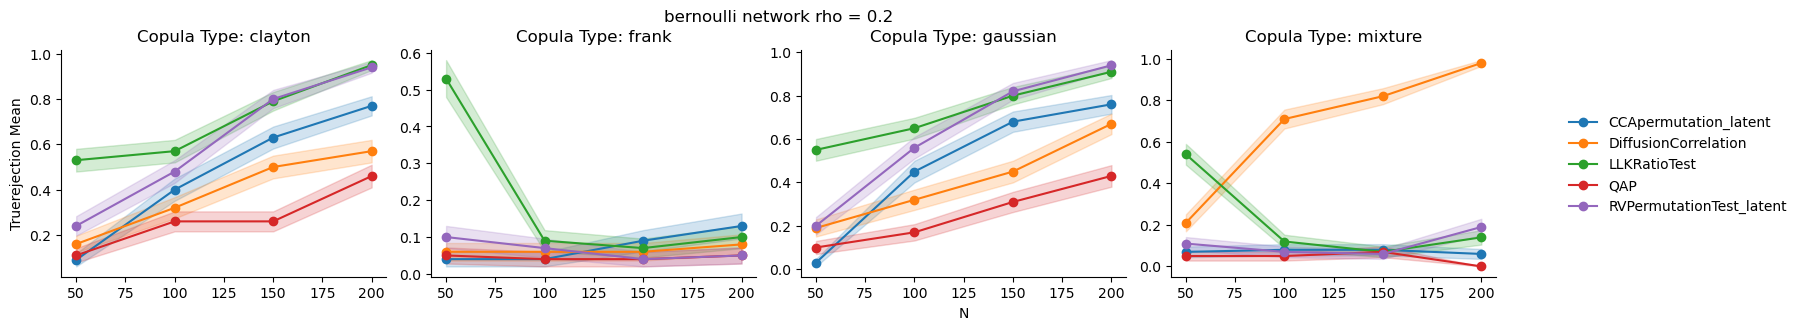

In [27]:
plot_grid(
    grouped_stats=agg_alt_02_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="bernoulli network rho = 0.2",
)